<a href="https://colab.research.google.com/github/subudear/deep-learning/blob/main/assignment1/GAN/dinov2_svm_petridish.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**# STEP 1: Imports**

In [ ]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report
import joblib

print('GPU available:', torch.cuda.is_available())
print('GPU name:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No GPU')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

GPU available: True
GPU name: Tesla T4
Using device: cuda


**# STEP 2: Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


**# STEP 3: Extract dataset zip files**

In [ ]:
dataset_path = '/content/drive/MyDrive/compx525assign1/cell_cultures'
extract_path = '/content/datasetsvm'

os.makedirs(extract_path, exist_ok=True)

for f in os.listdir(dataset_path):
    if f.endswith('.zip'):
        zip_path = os.path.join(dataset_path, f)
        print('Extracting:', zip_path)
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)

print('Extraction complete')
print('Extracted folders:', os.listdir(extract_path))

Extracting: /content/drive/MyDrive/compx525assign1/cell_cultures/test.zip
Extracting: /content/drive/MyDrive/compx525assign1/cell_cultures/train.zip
Extraction complete
Extracted folders: ['train', 'test']


**# STEP 4: Define paths & audit dataset**

In [ ]:
train_dir  = '/content/datasetsvm/train'
test_dir   = '/content/datasetsvm/test'
image_exts = ('.jpg', '.jpeg', '.png')

classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
print('Classes:', classes)
print('Number of classes:', len(classes))

for c in classes:
    n = sum(f.lower().endswith(image_exts) for f in os.listdir(os.path.join(train_dir, c)))
    print(f'  {c}: {n}')

print('Test images:', len([f for f in os.listdir(test_dir) if f.lower().endswith(image_exts)]))

Classes: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q']
Number of classes: 17
  a: 1283
  b: 4
  c: 475
  d: 266
  e: 117
  f: 59
  g: 720
  h: 5
  i: 199
  j: 0
  k: 12
  l: 660
  m: 543
  n: 91
  o: 197
  p: 35
  q: 29
Test images: 512


**# STEP 5: Build train DataFrame**

In [ ]:
rows = []
for cls in sorted(os.listdir(train_dir)):
    cls_path = os.path.join(train_dir, cls)
    if os.path.isdir(cls_path):
        for fname in os.listdir(cls_path):
            if fname.lower().endswith(image_exts):
                rows.append({'filepath': os.path.join(cls_path, fname), 'label': cls})

train_df = pd.DataFrame(rows)
print('Total training images:', len(train_df))
print(train_df['label'].value_counts().sort_index())

Total training images: 4695
label
a    1283
b       4
c     475
d     266
e     117
f      59
g     720
h       5
i     199
k      12
l     660
m     543
n      91
o     197
p      35
q      29
Name: count, dtype: int64


**# STEP 6: Train / Validation split**

In [ ]:
class_counts   = train_df['label'].value_counts()
EXTREME_CLASSES = class_counts[class_counts < 15].index.tolist()
extreme_df     = train_df[train_df['label'].isin(EXTREME_CLASSES)].copy()
normal_df      = train_df[~train_df['label'].isin(EXTREME_CLASSES)].copy()

train_split_df, val_split_df = train_test_split(
    normal_df, test_size=0.2, stratify=normal_df['label'], random_state=42
)
train_split_df = pd.concat([train_split_df, extreme_df], ignore_index=True)

print('Extreme minority classes (train only):', EXTREME_CLASSES)
print('Train size:', len(train_split_df))
print('Val size:  ', len(val_split_df))

Extreme minority classes (train only): ['k', 'h', 'b']
Train size: 3760
Val size:   935


**# STEP 7: Encode labels**

In [ ]:
label_to_idx = {label: idx for idx, label in enumerate(sorted(train_df['label'].unique()))}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}
num_classes  = len(label_to_idx)

train_split_df['label_idx'] = train_split_df['label'].map(label_to_idx)
val_split_df['label_idx']   = val_split_df['label'].map(label_to_idx)

print('Classes:', sorted(label_to_idx.keys()))
print('Num classes:', num_classes)
print('label_to_idx:', label_to_idx)

Classes: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'q']
Num classes: 16
label_to_idx: {'a': 0, 'b': 1, 'c': 2, 'd': 3, 'e': 4, 'f': 5, 'g': 6, 'h': 7, 'i': 8, 'k': 9, 'l': 10, 'm': 11, 'n': 12, 'o': 13, 'p': 14, 'q': 15}


**# STEP 8: Load frozen DINOv2 ViT-B/14**

In [ ]:
# DINOv2 ViT-B/14 — backbone frozen entirely, used as a fixed feature extractor.
# No weights are updated. The 768-dim CLS token is our embedding per image.
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')
dinov2 = dinov2.to(device)
dinov2.eval()
for param in dinov2.parameters():
    param.requires_grad = False

print('DINOv2 loaded and frozen.')
print(f'Total params: {sum(p.numel() for p in dinov2.parameters()):,}')
print('Embedding dim: 768 (CLS token)')

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:01<00:00, 306MB/s]


DINOv2 loaded and frozen.
Total params: 86,580,480
Embedding dim: 768 (CLS token)


**# STEP 9: Define image transform and Dataset**

In [ ]:
# DINOv2 ViT-B/14 expects 224x224 input with ImageNet normalisation.
# No augmentation — we want deterministic, consistent embeddings.
embed_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class EmbedDataset(Dataset):
    """Returns (image_tensor, label_idx) for labelled splits, or (image_tensor, filename) for test."""
    def __init__(self, df, transform, label_col='label_idx', filename_col=None):
        self.df           = df.reset_index(drop=True)
        self.transform    = transform
        self.label_col    = label_col
        self.filename_col = filename_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = self.transform(Image.open(row['filepath']).convert('RGB'))
        if self.filename_col:
            return image, row[self.filename_col]
        return image, int(row[self.label_col])


train_embed_ds = EmbedDataset(train_split_df, embed_transform)
val_embed_ds   = EmbedDataset(val_split_df,   embed_transform)

train_embed_loader = DataLoader(train_embed_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
val_embed_loader   = DataLoader(val_embed_ds,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train images: {len(train_embed_ds)}  |  Val images: {len(val_embed_ds)}')

Train images: 3760  |  Val images: 935


**# STEP 10: Extract DINOv2 embeddings**

In [ ]:
def extract_embeddings(loader, model, device):
    """Pass all images through frozen DINOv2 and collect 768-dim CLS embeddings."""
    all_embeddings, all_labels = [], []
    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(loader):
            embeddings = model(images.to(device))   # shape: [B, 768]
            all_embeddings.append(embeddings.cpu().numpy())
            all_labels.extend(labels.numpy() if hasattr(labels, 'numpy') else labels)
            if (batch_idx + 1) % 10 == 0:
                print(f'  Processed {(batch_idx+1) * loader.batch_size} / {len(loader.dataset)} images')
    return np.vstack(all_embeddings), np.array(all_labels)


print('Extracting TRAIN embeddings...')
X_train, y_train = extract_embeddings(train_embed_loader, dinov2, device)

print('Extracting VAL embeddings...')
X_val, y_val = extract_embeddings(val_embed_loader, dinov2, device)

print(f'\nX_train shape: {X_train.shape}  |  y_train shape: {y_train.shape}')
print(f'X_val shape:   {X_val.shape}  |  y_val shape:   {y_val.shape}')

Extracting TRAIN embeddings...
  Processed 640 / 3760 images
  Processed 1280 / 3760 images
  Processed 1920 / 3760 images
  Processed 2560 / 3760 images
  Processed 3200 / 3760 images
Extracting VAL embeddings...
  Processed 640 / 935 images

X_train shape: (3760, 768)  |  y_train shape: (3760,)
X_val shape:   (935, 768)  |  y_val shape:   (935,)


**# STEP 11: Save / load embeddings (optional — avoids re-extraction)**

In [ ]:
embed_dir = '/content/drive/MyDrive'

np.save(os.path.join(embed_dir, 'dinov2_X_train.npy'), X_train)
np.save(os.path.join(embed_dir, 'dinov2_y_train.npy'), y_train)
np.save(os.path.join(embed_dir, 'dinov2_X_val.npy'),   X_val)
np.save(os.path.join(embed_dir, 'dinov2_y_val.npy'),   y_val)
print('Embeddings saved to Drive.')

# To reload on a fresh session without re-extracting:
# X_train = np.load(os.path.join(embed_dir, 'dinov2_X_train.npy'))
# y_train = np.load(os.path.join(embed_dir, 'dinov2_y_train.npy'))
# X_val   = np.load(os.path.join(embed_dir, 'dinov2_X_val.npy'))
# y_val   = np.load(os.path.join(embed_dir, 'dinov2_y_val.npy'))

Embeddings saved to Drive.


**# STEP 12: Train SVM classifier (RBF kernel)**

In [ ]:
# Pipeline: StandardScaler (zero-mean, unit-variance) → SVM with RBF kernel.
# class_weight='balanced' compensates for class imbalance without oversampling.
# C=10, gamma='scale' are strong defaults for high-dim DINOv2 embeddings.
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(
        kernel='rbf',
        C=10,
        gamma='scale',
        class_weight='balanced',
        probability=True,      # enables predict_proba for confidence scores
        random_state=42,
        verbose=True,
    ))
])

print('Training SVM...')
svm_pipeline.fit(X_train, y_train)
print('SVM training complete.')

Training SVM...
[LibSVM]SVM training complete.


**# STEP 13: Evaluate SVM on validation set**

Validation Accuracy: 0.6011


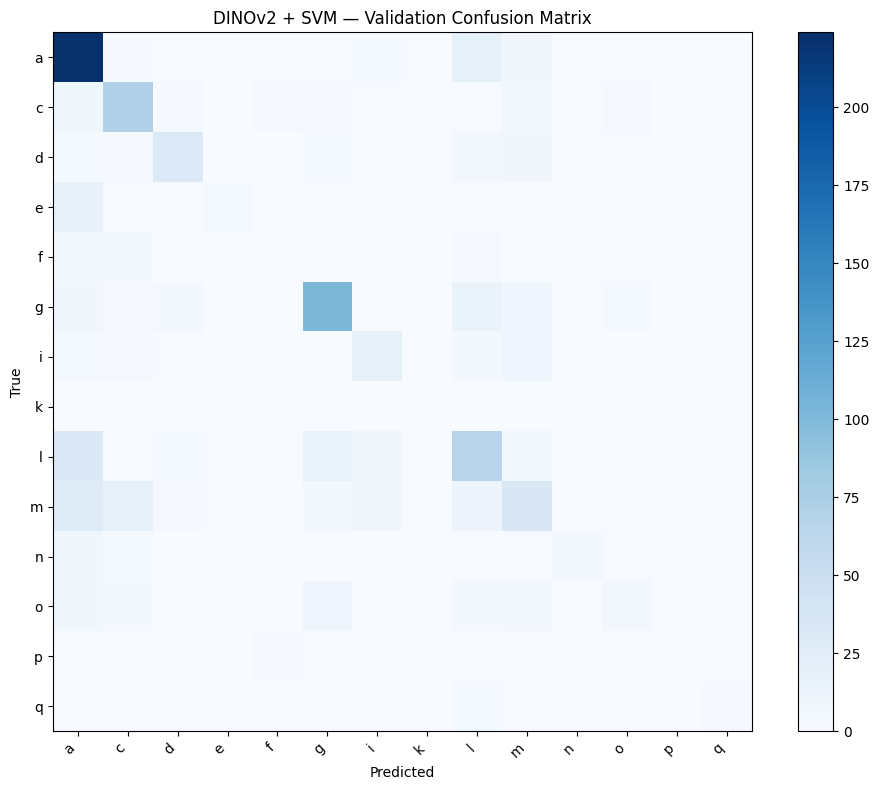

              precision    recall  f1-score   support

           a       0.66      0.87      0.75       257
           c       0.62      0.75      0.68        95
           d       0.70      0.57      0.62        53
           e       0.60      0.13      0.21        23
           f       0.00      0.00      0.00        12
           g       0.74      0.71      0.72       144
           i       0.46      0.47      0.47        40
           k       0.00      0.00      0.00         0
           l       0.49      0.50      0.50       132
           m       0.38      0.31      0.34       109
           n       0.80      0.22      0.35        18
           o       0.38      0.15      0.22        39
           p       0.50      0.14      0.22         7
           q       1.00      0.33      0.50         6

    accuracy                           0.60       935
   macro avg       0.52      0.37      0.40       935
weighted avg       0.59      0.60      0.58       935



In [ ]:
y_pred = svm_pipeline.predict(X_val)
val_acc = (y_pred == y_val).mean()
print(f'Validation Accuracy: {val_acc:.4f}')

# Build confusion matrix
present_labels = sorted(set(y_val) | set(y_pred))
class_names    = [idx_to_label[i] for i in present_labels]

cm = confusion_matrix(y_val, y_pred, labels=present_labels)
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('DINOv2 + SVM — Validation Confusion Matrix')
plt.colorbar()
tick_marks = range(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha='right')
plt.yticks(tick_marks, class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

print(classification_report(
    y_val, y_pred,
    labels=present_labels,
    target_names=class_names,
    zero_division=0
))

**# STEP 13b: Per-class Precision / Recall / F1 bar chart**

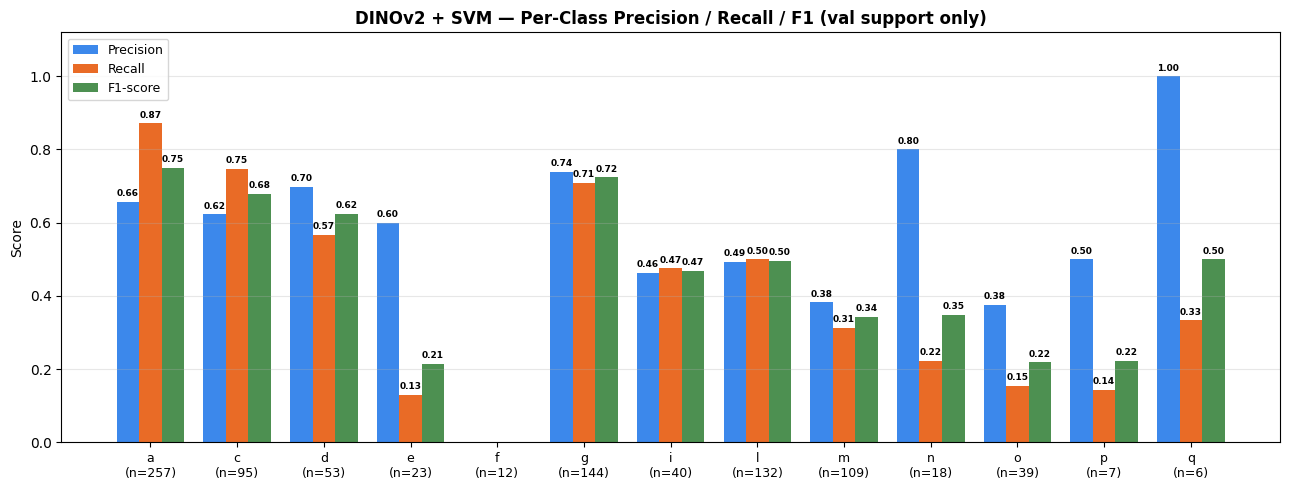

In [ ]:
from sklearn.metrics import precision_recall_fscore_support
import warnings
warnings.filterwarnings('ignore')

present_labels = sorted(set(y_val) | set(y_pred))
class_names    = [idx_to_label[i] for i in present_labels]
support        = [list(y_val).count(i) for i in present_labels]

prec, rec, f1, _ = precision_recall_fscore_support(
    y_val, y_pred, labels=present_labels, zero_division=0
)

# Only plot classes that have val support > 0
has_support = [i for i, s in enumerate(support) if s > 0]
cls_plot    = [class_names[i] for i in has_support]
prec_plot   = prec[has_support]
rec_plot    = rec[has_support]
f1_plot     = f1[has_support]
sup_plot    = [support[i] for i in has_support]

x = np.arange(len(cls_plot))
w = 0.26

fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x - w,   prec_plot, w, label='Precision', color='#1A73E8', alpha=0.85)
b2 = ax.bar(x,       rec_plot,  w, label='Recall',    color='#E65100', alpha=0.85)
b3 = ax.bar(x + w,   f1_plot,   w, label='F1-score',  color='#2E7D32', alpha=0.85)

for bar in list(b1) + list(b2) + list(b3):
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.2f}', ha='center', va='bottom', fontsize=6.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([f'{c}\n(n={s})' for c, s in zip(cls_plot, sup_plot)], fontsize=9)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=10)
ax.set_title('DINOv2 + SVM — Per-Class Precision / Recall / F1 (val support only)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**# STEP 13c: F1-score heatmap — DINOv2+SVM vs DINOv2 fine-tuned vs ResNet50**

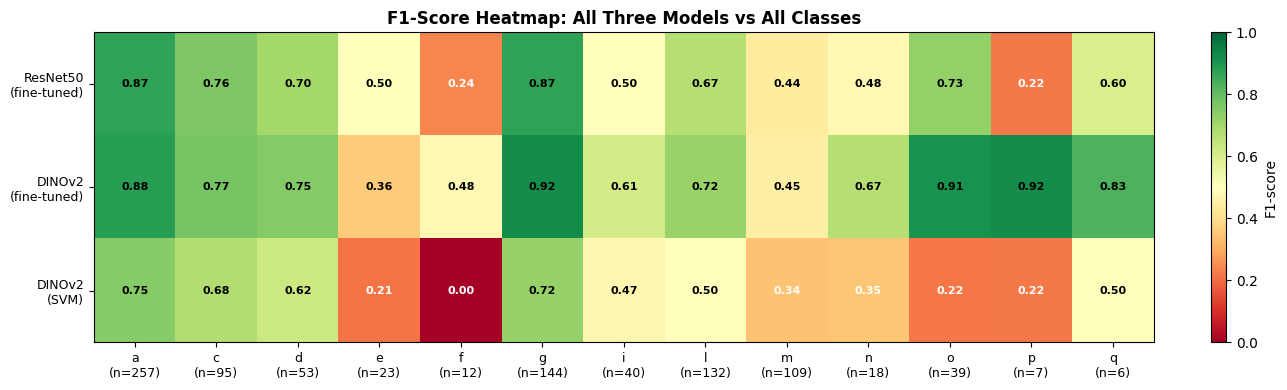

In [ ]:
# Reference F1 scores from the other two models (from their classification reports)
# Classes with val support > 0 only
ALL_CLASSES   = ['a','b','c','d','e','f','g','h','i','k','l','m','n','o','p','q']
ALL_SUPPORT   = [257, 0, 95, 53, 23, 12, 144, 0, 40, 0, 132, 109, 18, 39, 7, 6]
F1_RESNET     = [0.87,0.00,0.76,0.70,0.50,0.24,0.87,0.00,0.50,0.00,0.67,0.44,0.48,0.73,0.22,0.60]
F1_DINOV2_FT  = [0.88,0.00,0.77,0.75,0.36,0.48,0.92,0.00,0.61,0.00,0.72,0.45,0.67,0.91,0.92,0.83]

# Build SVM F1 array aligned to ALL_CLASSES
f1_svm_full = []
for cls in ALL_CLASSES:
    if cls in class_names:
        idx = class_names.index(cls)
        f1_svm_full.append(float(f1[idx]))
    else:
        f1_svm_full.append(0.0)

# Filter to supported classes only
sup_idx   = [i for i, s in enumerate(ALL_SUPPORT) if s > 0]
cls_sup   = [ALL_CLASSES[i] for i in sup_idx]
sup_vals  = [ALL_SUPPORT[i] for i in sup_idx]

data = np.array([
    [F1_RESNET[i]    for i in sup_idx],
    [F1_DINOV2_FT[i] for i in sup_idx],
    [f1_svm_full[i]  for i in sup_idx],
])

fig, ax = plt.subplots(figsize=(13, 4))
im = ax.imshow(data, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(cls_sup)))
ax.set_xticklabels([f'{c}\n(n={s})' for c, s in zip(cls_sup, sup_vals)], fontsize=9)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['ResNet50\n(fine-tuned)', 'DINOv2\n(fine-tuned)', 'DINOv2\n(SVM)'], fontsize=9)
for i in range(len(cls_sup)):
    for j, vals in enumerate([F1_RESNET, F1_DINOV2_FT, f1_svm_full]):
        v = vals[sup_idx[i]]
        ax.text(i, j, f'{v:.2f}', ha='center', va='center', fontsize=8,
                color='white' if v < 0.35 else 'black', fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.02, label='F1-score')
ax.set_title('F1-Score Heatmap: All Three Models vs All Classes', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

**# STEP 13d: Overall metrics bar chart — all three models**

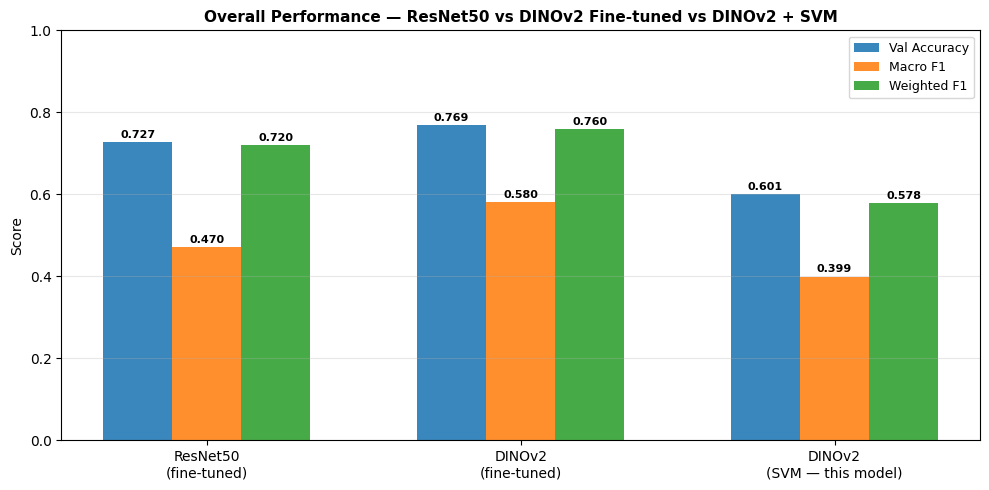


DINOv2 + SVM results:
  Val Accuracy : 0.6011
  Macro F1     : 0.3992
  Weighted F1  : 0.5779


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

# Compute live SVM metrics
svm_val_acc      = accuracy_score(y_val, y_pred)
svm_macro_f1     = f1_score(y_val, y_pred, average='macro',    zero_division=0)
svm_weighted_f1  = f1_score(y_val, y_pred, average='weighted', zero_division=0)

# Reference results from the other models
models  = ['ResNet50\n(fine-tuned)', 'DINOv2\n(fine-tuned)', 'DINOv2\n(SVM — this model)']
val_acc = [0.727, 0.769, svm_val_acc]
mac_f1  = [0.47,  0.58,  svm_macro_f1]
wgt_f1  = [0.72,  0.76,  svm_weighted_f1]
colors  = ['#1A73E8', '#2E7D32', '#E65100']

metrics     = ['Val Accuracy', 'Macro F1', 'Weighted F1']
metric_vals = [val_acc, mac_f1, wgt_f1]

x = np.arange(len(models))
w = 0.22

fig, ax = plt.subplots(figsize=(10, 5))
for i, (metric, vals) in enumerate(zip(metrics, metric_vals)):
    bars = ax.bar(x + (i-1)*w, vals, w, label=metric, alpha=0.88)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score', fontsize=10)
ax.set_title('Overall Performance — ResNet50 vs DINOv2 Fine-tuned vs DINOv2 + SVM', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nDINOv2 + SVM results:')
print(f'  Val Accuracy : {svm_val_acc:.4f}')
print(f'  Macro F1     : {svm_macro_f1:.4f}')
print(f'  Weighted F1  : {svm_weighted_f1:.4f}')

**# STEP 13e: SVM decision confidence — top-N confidence score distribution**

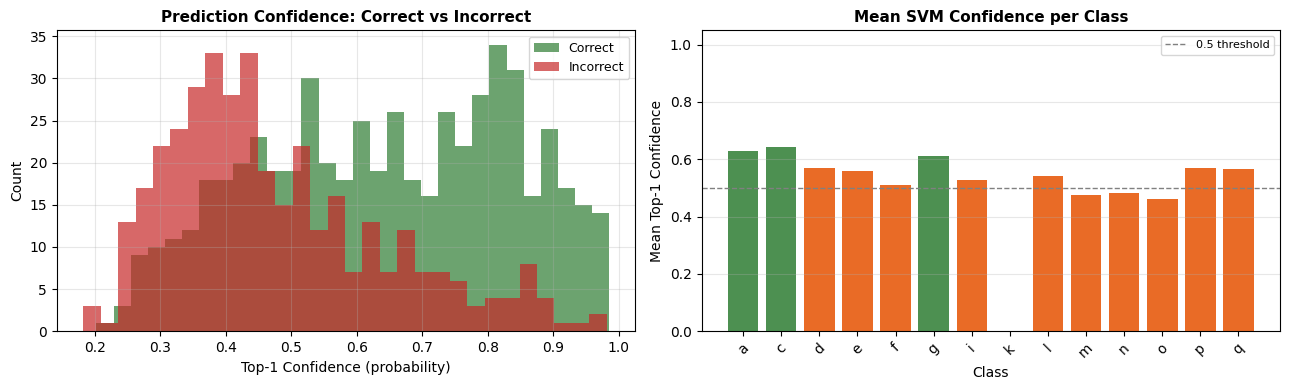

Mean confidence (correct):   0.6428
Mean confidence (incorrect): 0.4761


In [ ]:
# SVM predict_proba gives a probability per class.
# Top-1 confidence = max probability. High = model is decisive; low = uncertain.
proba       = svm_pipeline.predict_proba(X_val)   # shape: [N, num_classes]
top1_conf   = proba.max(axis=1)                   # highest probability per sample
correct_mask = (y_pred == y_val)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: confidence distribution split by correct vs incorrect
axes[0].hist(top1_conf[correct_mask],  bins=30, color='#2E7D32', alpha=0.7, label='Correct')
axes[0].hist(top1_conf[~correct_mask], bins=30, color='#C62828', alpha=0.7, label='Incorrect')
axes[0].set_xlabel('Top-1 Confidence (probability)', fontsize=10)
axes[0].set_ylabel('Count', fontsize=10)
axes[0].set_title('Prediction Confidence: Correct vs Incorrect', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Right: per-class mean confidence
mean_conf_per_class = []
for i in present_labels:
    mask = y_val == i
    if mask.sum() > 0:
        mean_conf_per_class.append(top1_conf[mask].mean())
    else:
        mean_conf_per_class.append(0.0)

bar_colors = ['#2E7D32' if f > 0.6 else '#E65100' if f > 0.4 else '#C62828'
              for f in mean_conf_per_class]
axes[1].bar(class_names, mean_conf_per_class, color=bar_colors, alpha=0.85)
axes[1].axhline(0.5, color='grey', linestyle='--', linewidth=1, label='0.5 threshold')
axes[1].set_ylim(0, 1.05)
axes[1].set_xlabel('Class', fontsize=10)
axes[1].set_ylabel('Mean Top-1 Confidence', fontsize=10)
axes[1].set_title('Mean SVM Confidence per Class', fontsize=11, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(fontsize=8)
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Mean confidence (correct):   {top1_conf[correct_mask].mean():.4f}')
print(f'Mean confidence (incorrect): {top1_conf[~correct_mask].mean():.4f}')

**# STEP 13f: UMAP / t-SNE embedding visualisation**

Running t-SNE on val embeddings (768 → 2 dims)...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 935 samples in 0.001s...
[t-SNE] Computed neighbors for 935 samples in 0.172s...
[t-SNE] Computed conditional probabilities for sample 935 / 935
[t-SNE] Mean sigma: 6.706428
[t-SNE] KL divergence after 250 iterations with early exaggeration: 67.202957
[t-SNE] KL divergence after 1000 iterations: 1.497301


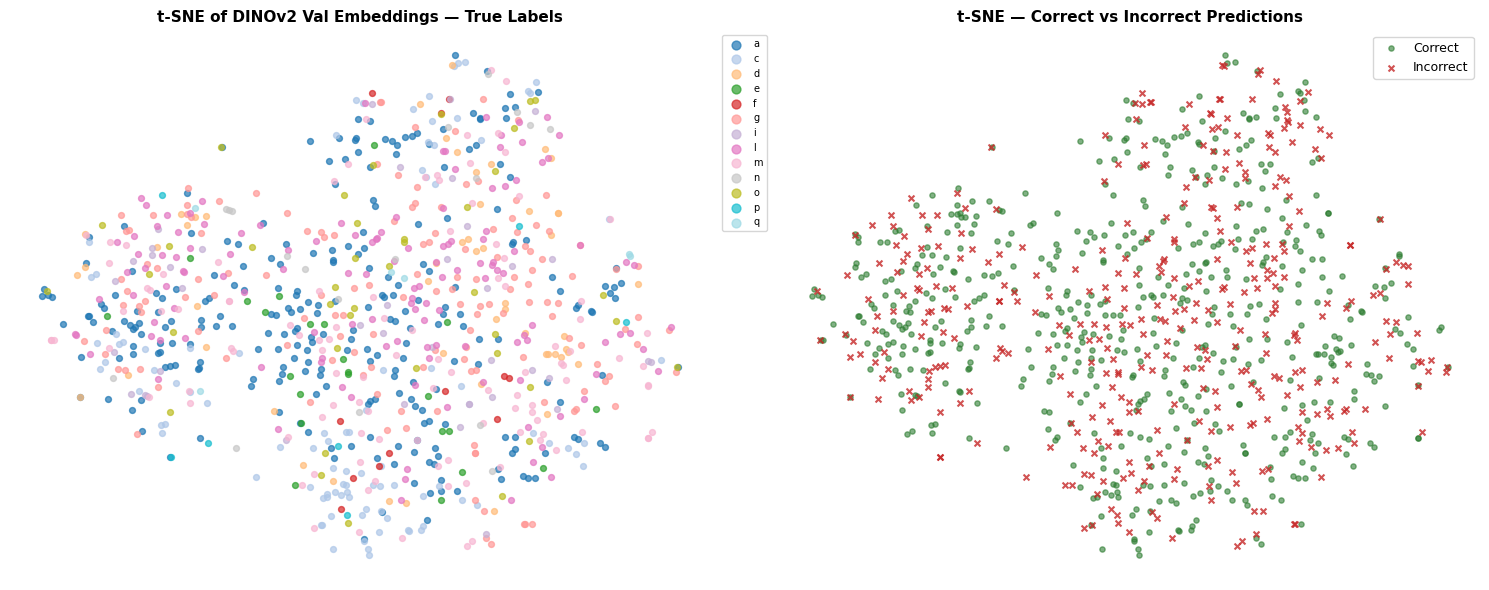

t-SNE complete.


In [ ]:
# Visualise the 768-dim DINOv2 embeddings in 2D using t-SNE.
# Well-separated clusters = DINOv2 learned discriminative features for these classes.
# Overlapping clusters = classes the SVM will confuse.
try:
    from sklearn.manifold import TSNE
    print('Running t-SNE on val embeddings (768 → 2 dims)...')
    tsne   = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000, verbose=1)
    X_2d   = tsne.fit_transform(X_val)

    cmap   = plt.get_cmap('tab20', len(present_labels))
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Left: colour by TRUE label
    for i, lbl in enumerate(present_labels):
        mask = y_val == lbl
        if mask.sum() == 0:
            continue
        axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1], c=[cmap(i)],
                        label=idx_to_label[lbl], alpha=0.7, s=18)
    axes[0].set_title('t-SNE of DINOv2 Val Embeddings — True Labels', fontsize=11, fontweight='bold')
    axes[0].legend(fontsize=7, markerscale=1.5, bbox_to_anchor=(1.01, 1), loc='upper left')
    axes[0].axis('off')

    # Right: colour by CORRECT (green) vs INCORRECT (red)
    axes[1].scatter(X_2d[correct_mask,  0], X_2d[correct_mask,  1],
                    c='#2E7D32', alpha=0.6, s=14, label='Correct')
    axes[1].scatter(X_2d[~correct_mask, 0], X_2d[~correct_mask, 1],
                    c='#C62828', alpha=0.8, s=18, marker='x', label='Incorrect')
    axes[1].set_title('t-SNE — Correct vs Incorrect Predictions', fontsize=11, fontweight='bold')
    axes[1].legend(fontsize=9)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()
    print('t-SNE complete.')
except Exception as e:
    print(f'Error: {e}')

**# STEP 14: Save SVM model**

In [ ]:
svm_path = '/content/drive/MyDrive/dinov2_svm_pipeline_final.pkl'
joblib.dump(svm_pipeline, svm_path)
print(f'SVM pipeline saved to: {svm_path}')

# Save label mappings alongside
import json
with open('/content/drive/MyDrive/dinov2_svm_label_mappings_final.json', 'w') as f:
    json.dump({'label_to_idx': label_to_idx, 'idx_to_label': {str(k): v for k, v in idx_to_label.items()}}, f)
print('Label mappings saved.')

SVM pipeline saved to: /content/drive/MyDrive/dinov2_svm_pipeline.pkl
Label mappings saved.


**# STEP 15: Build test DataLoader & extract test embeddings**

In [ ]:
test_rows = [
    {'filepath': os.path.join(test_dir, f), 'filename': f}
    for f in sorted(os.listdir(test_dir)) if f.lower().endswith(image_exts)
]
test_df = pd.DataFrame(test_rows)
print(f'Test images: {len(test_df)}')

test_embed_ds     = EmbedDataset(test_df, embed_transform, filename_col='filename')
test_embed_loader = DataLoader(test_embed_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print('Extracting test embeddings...')
all_test_embeddings, all_test_filenames = [], []
with torch.no_grad():
    for images, filenames in test_embed_loader:
        embeddings = dinov2(images.to(device)).cpu().numpy()
        all_test_embeddings.append(embeddings)
        all_test_filenames.extend(filenames)

X_test = np.vstack(all_test_embeddings)
print(f'X_test shape: {X_test.shape}')

Test images: 512
Extracting test embeddings...
X_test shape: (512, 768)


**# STEP 16: Generate submission CSV**

In [ ]:
test_preds      = svm_pipeline.predict(X_test)
test_pred_labels = [idx_to_label[p] for p in test_preds]

submission_df = pd.DataFrame({
    'TestFileName': all_test_filenames,
    'Class':        test_pred_labels,
})

csv_path = '/content/drive/MyDrive/dinov2_svm_submission_final.csv'
submission_df.to_csv(csv_path, index=False)

print(submission_df.head(10))
print(f'\nPrediction distribution:\n{submission_df["Class"].value_counts().sort_index()}')
print(f'\nSaved to: {csv_path}')

      TestFileName Class
0    z10002793.jpg     l
1  z1002467769.jpg     l
2  z1002525907.jpg     a
3  z1004350237.jpg     c
4   z100756404.jpg     i
5  z1010716305.jpg     a
6  z1011639766.jpg     m
7  z1019401380.jpg     a
8  z1021646945.jpg     c
9  z1023721673.jpg     a

Prediction distribution:
Class
a    215
c     62
d     16
e      2
g     66
i     16
l     75
m     52
n      1
o      6
q      1
Name: count, dtype: int64

Saved to: /content/drive/MyDrive/dinov2_svm_submission.csv
